# EDA Outlier Check - java-ash-hysplit
Notebook ini digunakan untuk mengecek outlier pada dataset `java-ash-hysplit.csv` menggunakan pendekatan statistik (IQR) dan visualisasi.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

In [3]:
# Path dataset
DATA_PATH = Path(r'D:\Projects\volcanic_ash\modeling\java-ash-hysplit.csv')
if not DATA_PATH.exists():
    raise FileNotFoundError(f'Dataset tidak ditemukan: {DATA_PATH}')

df = pd.read_csv(DATA_PATH)
df.columns = [c.strip() for c in df.columns]  # Bersihkan spasi tersembunyi di header

print('Shape:', df.shape)
display(df.head(5))

Shape: (1707, 16)


,id,timestamp,volcano_filter,alert_level,latitude,longitude,elevation,tinggi_letusan_m,kec_angin_km_jam,arah_angin_deg,amplitudo,duration,jarak_km,luas_km2,sudut_deg,radius_km
0,1,2024-06-11 07:34:00 UTC,Merapi,Yellow,-7.54194,110.44194,2968,1000.0,4.7,270.0,50.0,30.0,32.511505,614.390650,303.257335,18.304149
1,2,2024-01-24 08:56:00 UTC,Merapi,Orange,-7.54194,110.44194,2968,1000.0,8.0,135.0,51.0,168.0,27.761756,460.792988,37.901873,15.892819
2,3,2023-03-15 03:36:00 UTC,Merapi,Orange,-7.54194,110.44194,2968,1200.0,7.1,90.0,65.0,133.0,44.625714,614.214150,265.635506,23.934437
3,4,2023-03-13 22:50:00 UTC,Merapi,Orange,-7.54194,110.44194,2968,1500.0,3.2,135.0,70.0,160.0,22.998759,184.285530,288.108280,11.770659
4,5,2023-03-12 09:19:00 UTC,Merapi,Orange,-7.54194,110.44194,2968,2500.0,8.3,315.0,70.0,145.0,39.159595,307.107075,270.462663,20.809694


In [4]:
# Ringkasan awal
print('Info kolom:')
display(pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_count': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2)
}).sort_values(['missing_count', 'dtype'], ascending=[False, True]))

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print('Jumlah kolom numerik:', len(numeric_cols))
print('Kolom numerik:', numeric_cols)

Info kolom:


,dtype,missing_count,missing_pct
latitude,float64,0,0.0
longitude,float64,0,0.0
tinggi_letusan_m,float64,0,0.0
kec_angin_km_jam,float64,0,0.0
arah_angin_deg,float64,0,0.0
amplitudo,float64,0,0.0
duration,float64,0,0.0
jarak_km,float64,0,0.0
luas_km2,float64,0,0.0
sudut_deg,float64,0,0.0


Jumlah kolom numerik: 13
Kolom numerik: ['id', 'latitude', 'longitude', 'elevation', 'tinggi_letusan_m', 'kec_angin_km_jam', 'arah_angin_deg', 'amplitudo', 'duration', 'jarak_km', 'luas_km2', 'sudut_deg', 'radius_km']


In [5]:
# Statistik deskriptif kolom numerik
desc = df[numeric_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
desc['iqr'] = desc['75%'] - desc['25%']
display(desc)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,iqr
id,1707.0,854.949619,493.850759,1.000000,18.060000,86.300000,427.500000,854.000000,1282.500000,1624.700000,1692.940000,1710.000000,855.000000
latitude,1707.0,-8.091564,0.092315,-8.125000,-8.125000,-8.108050,-8.108050,-8.108050,-8.108050,-8.108050,-7.541940,-7.241944,0.000000
longitude,1707.0,112.902040,0.457298,109.208056,110.441940,112.920000,112.920000,112.920000,112.920000,112.950000,114.041944,114.041944,0.000000
elevation,1707.0,3622.638547,209.815327,2329.000000,2329.000000,3332.000000,3676.000000,3676.000000,3676.000000,3676.000000,3676.000000,3676.000000,0.000000
tinggi_letusan_m,1707.0,1225.902168,2773.045787,100.000000,200.000000,300.000000,500.000000,700.000000,800.000000,2000.000000,15957.940000,27770.000000,300.000000
kec_angin_km_jam,1707.0,4.363035,3.002966,0.000000,0.400000,0.700000,1.950000,3.700000,6.100000,10.200000,13.300000,16.400000,4.150000
arah_angin_deg,1707.0,138.663738,106.246295,0.000000,0.000000,0.000000,22.500000,180.000000,225.000000,270.000000,337.500000,337.500000,202.500000
amplitudo,1707.0,21.874634,8.969963,2.000000,3.000000,9.000000,22.000000,22.000000,22.000000,22.000000,70.000000,222.000000,0.000000
duration,1707.0,126.506151,72.093476,14.000000,63.060000,84.000000,107.000000,121.000000,134.000000,173.700000,269.700000,2388.000000,27.000000
jarak_km,1707.0,20.697662,20.167916,0.216830,5.342916,7.671131,12.213570,17.356332,23.318955,45.368224,129.034109,218.555416,11.105385


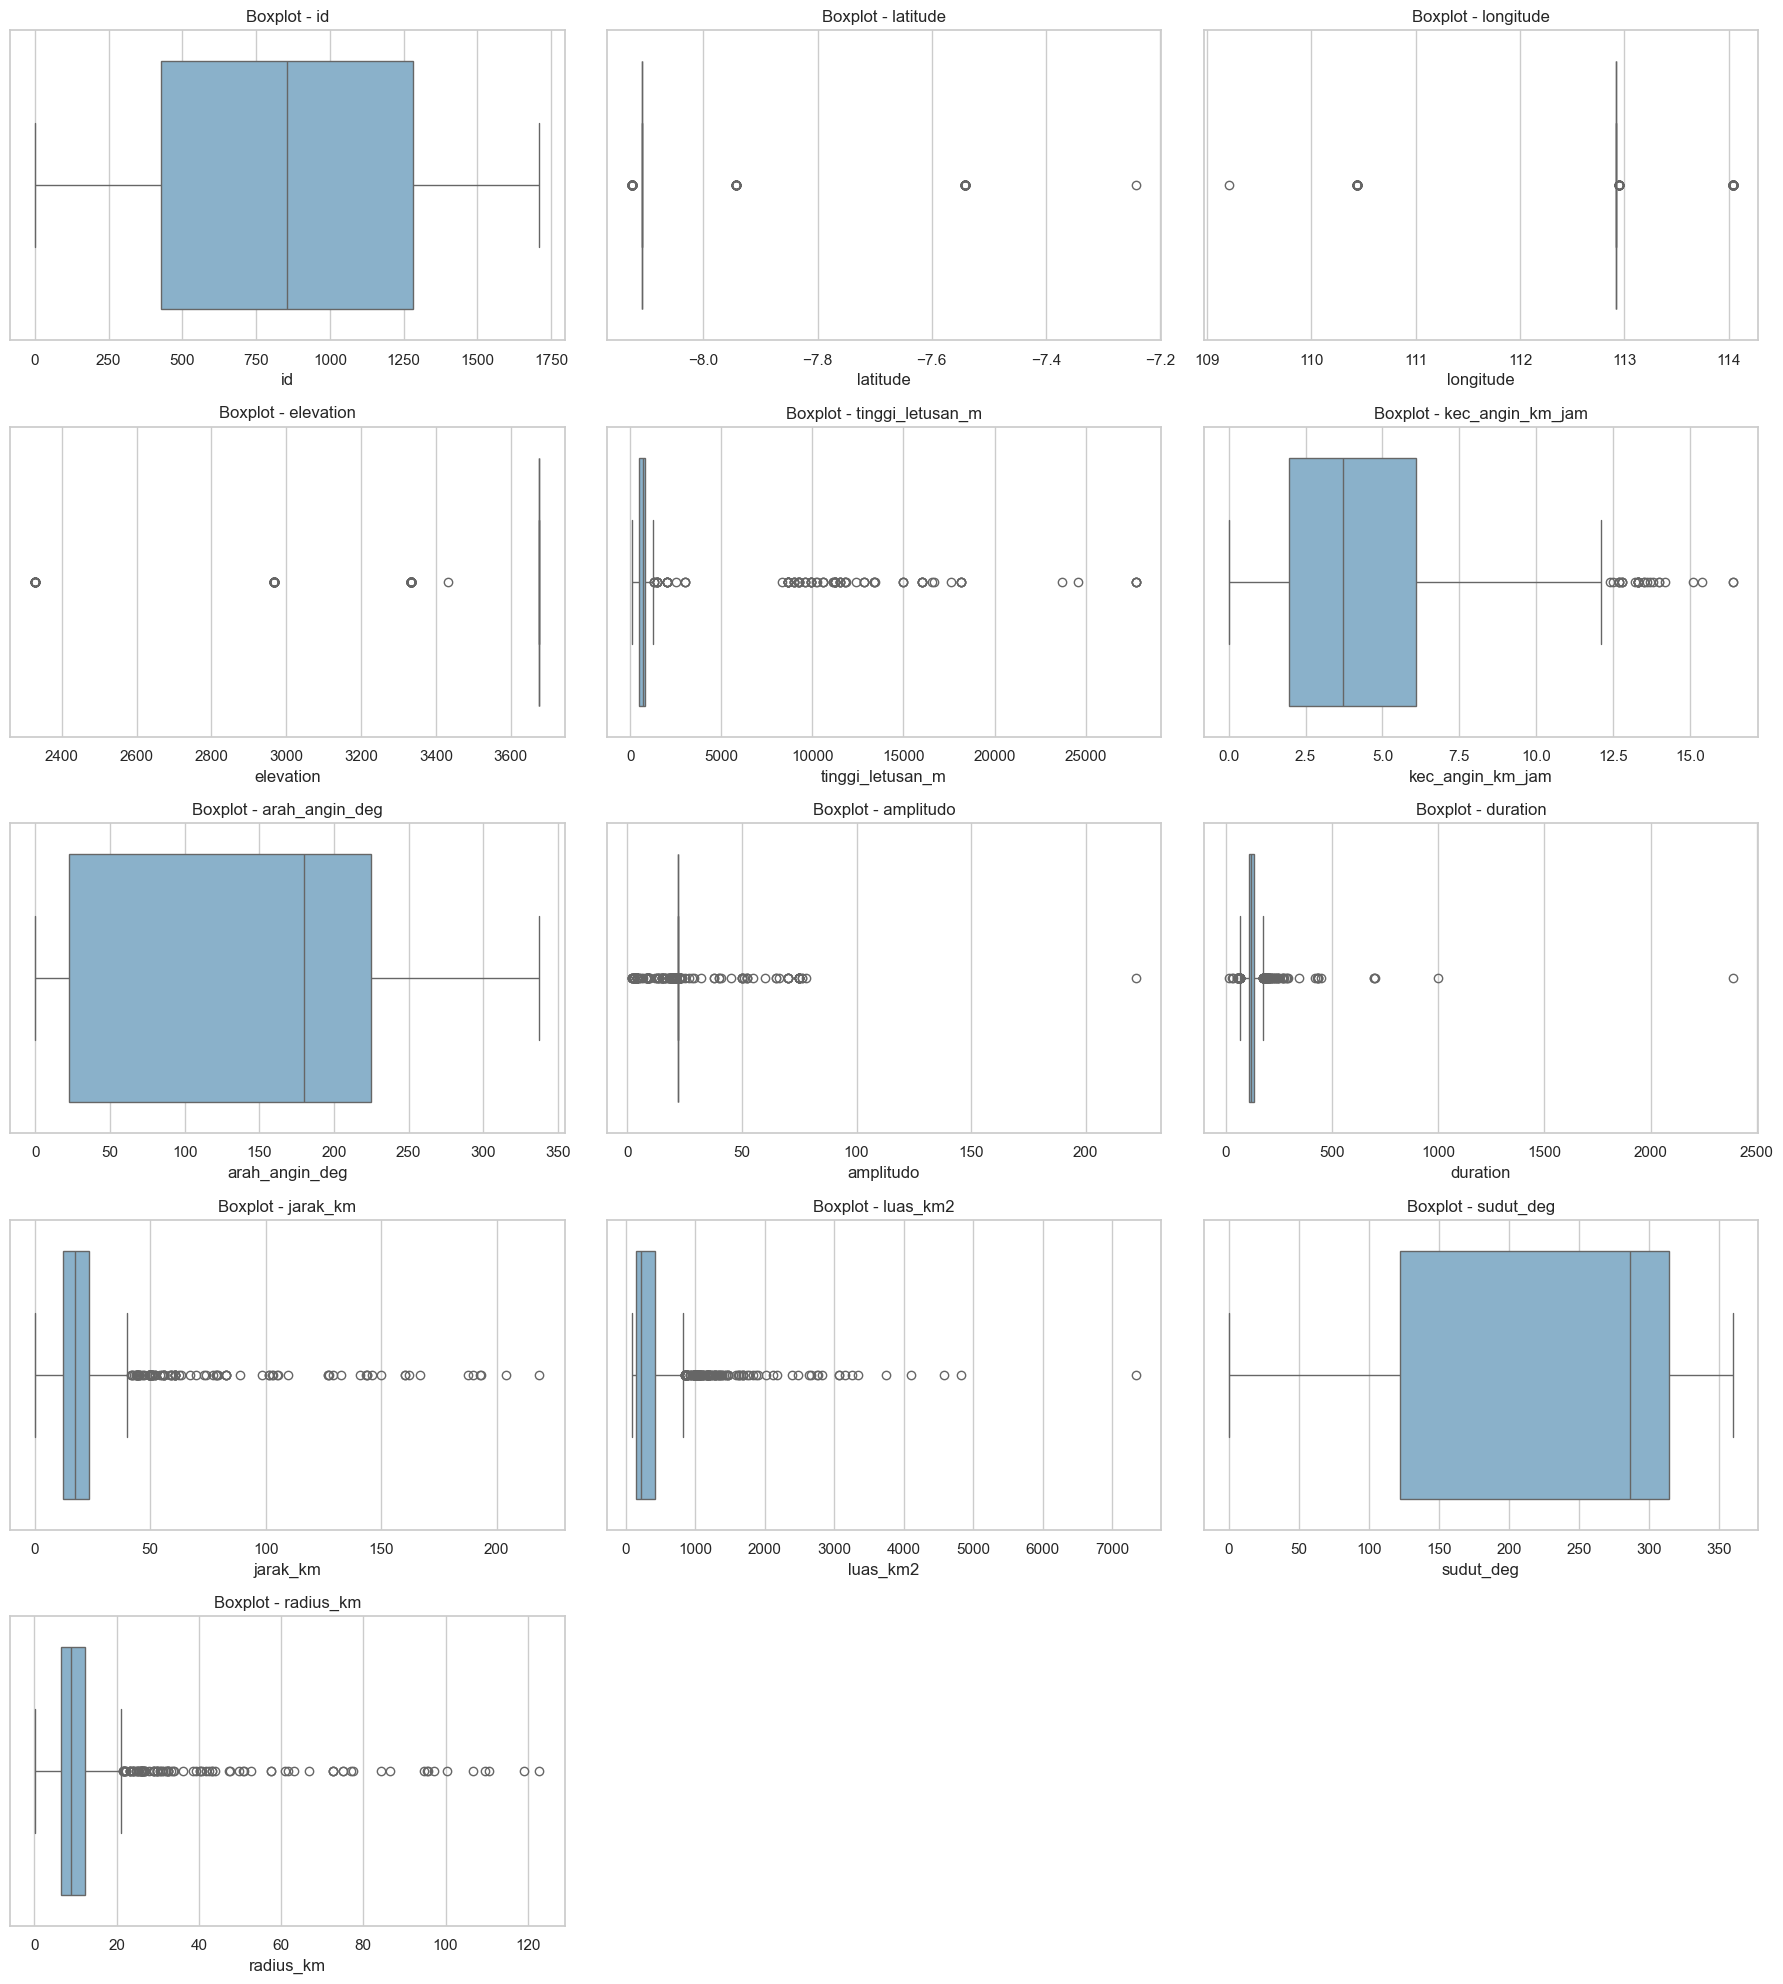

In [6]:
# Boxplot semua kolom numerik (untuk inspeksi cepat outlier)
n = len(numeric_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='#7FB3D5')
    axes[i].set_title(f'Boxplot - {col}')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [7]:
# Deteksi outlier berbasis IQR per kolom
rows = []
for col in numeric_cols:
    s = df[col].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask = (df[col] < lower) | (df[col] > upper)
    out_count = int(mask.sum())
    out_pct = float((out_count / len(df)) * 100)

    rows.append({
        'column': col,
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'lower_bound': lower,
        'upper_bound': upper,
        'outlier_count': out_count,
        'outlier_pct': round(out_pct, 2)
    })

outlier_report = pd.DataFrame(rows).sort_values('outlier_pct', ascending=False).reset_index(drop=True)
display(outlier_report)

,column,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_pct
0,amplitudo,22.000000,22.000000,0.000000,22.000000,22.000000,491,28.76
1,latitude,-8.108050,-8.108050,0.000000,-8.108050,-8.108050,139,8.14
2,longitude,112.920000,112.920000,0.000000,112.920000,112.920000,139,8.14
3,elevation,3676.000000,3676.000000,0.000000,3676.000000,3676.000000,139,8.14
4,luas_km2,153.371627,429.427267,276.055640,-260.711834,843.510728,139,8.14
5,duration,107.000000,134.000000,27.000000,66.500000,174.500000,112,6.56
6,radius_km,6.416442,12.374528,5.958086,-2.520688,21.311657,101,5.92
7,jarak_km,12.213570,23.318955,11.105385,-4.444508,39.977033,100,5.86
8,tinggi_letusan_m,500.000000,800.000000,300.000000,50.000000,1250.000000,99,5.80
9,kec_angin_km_jam,1.950000,6.100000,4.150000,-4.275000,12.325000,28,1.64


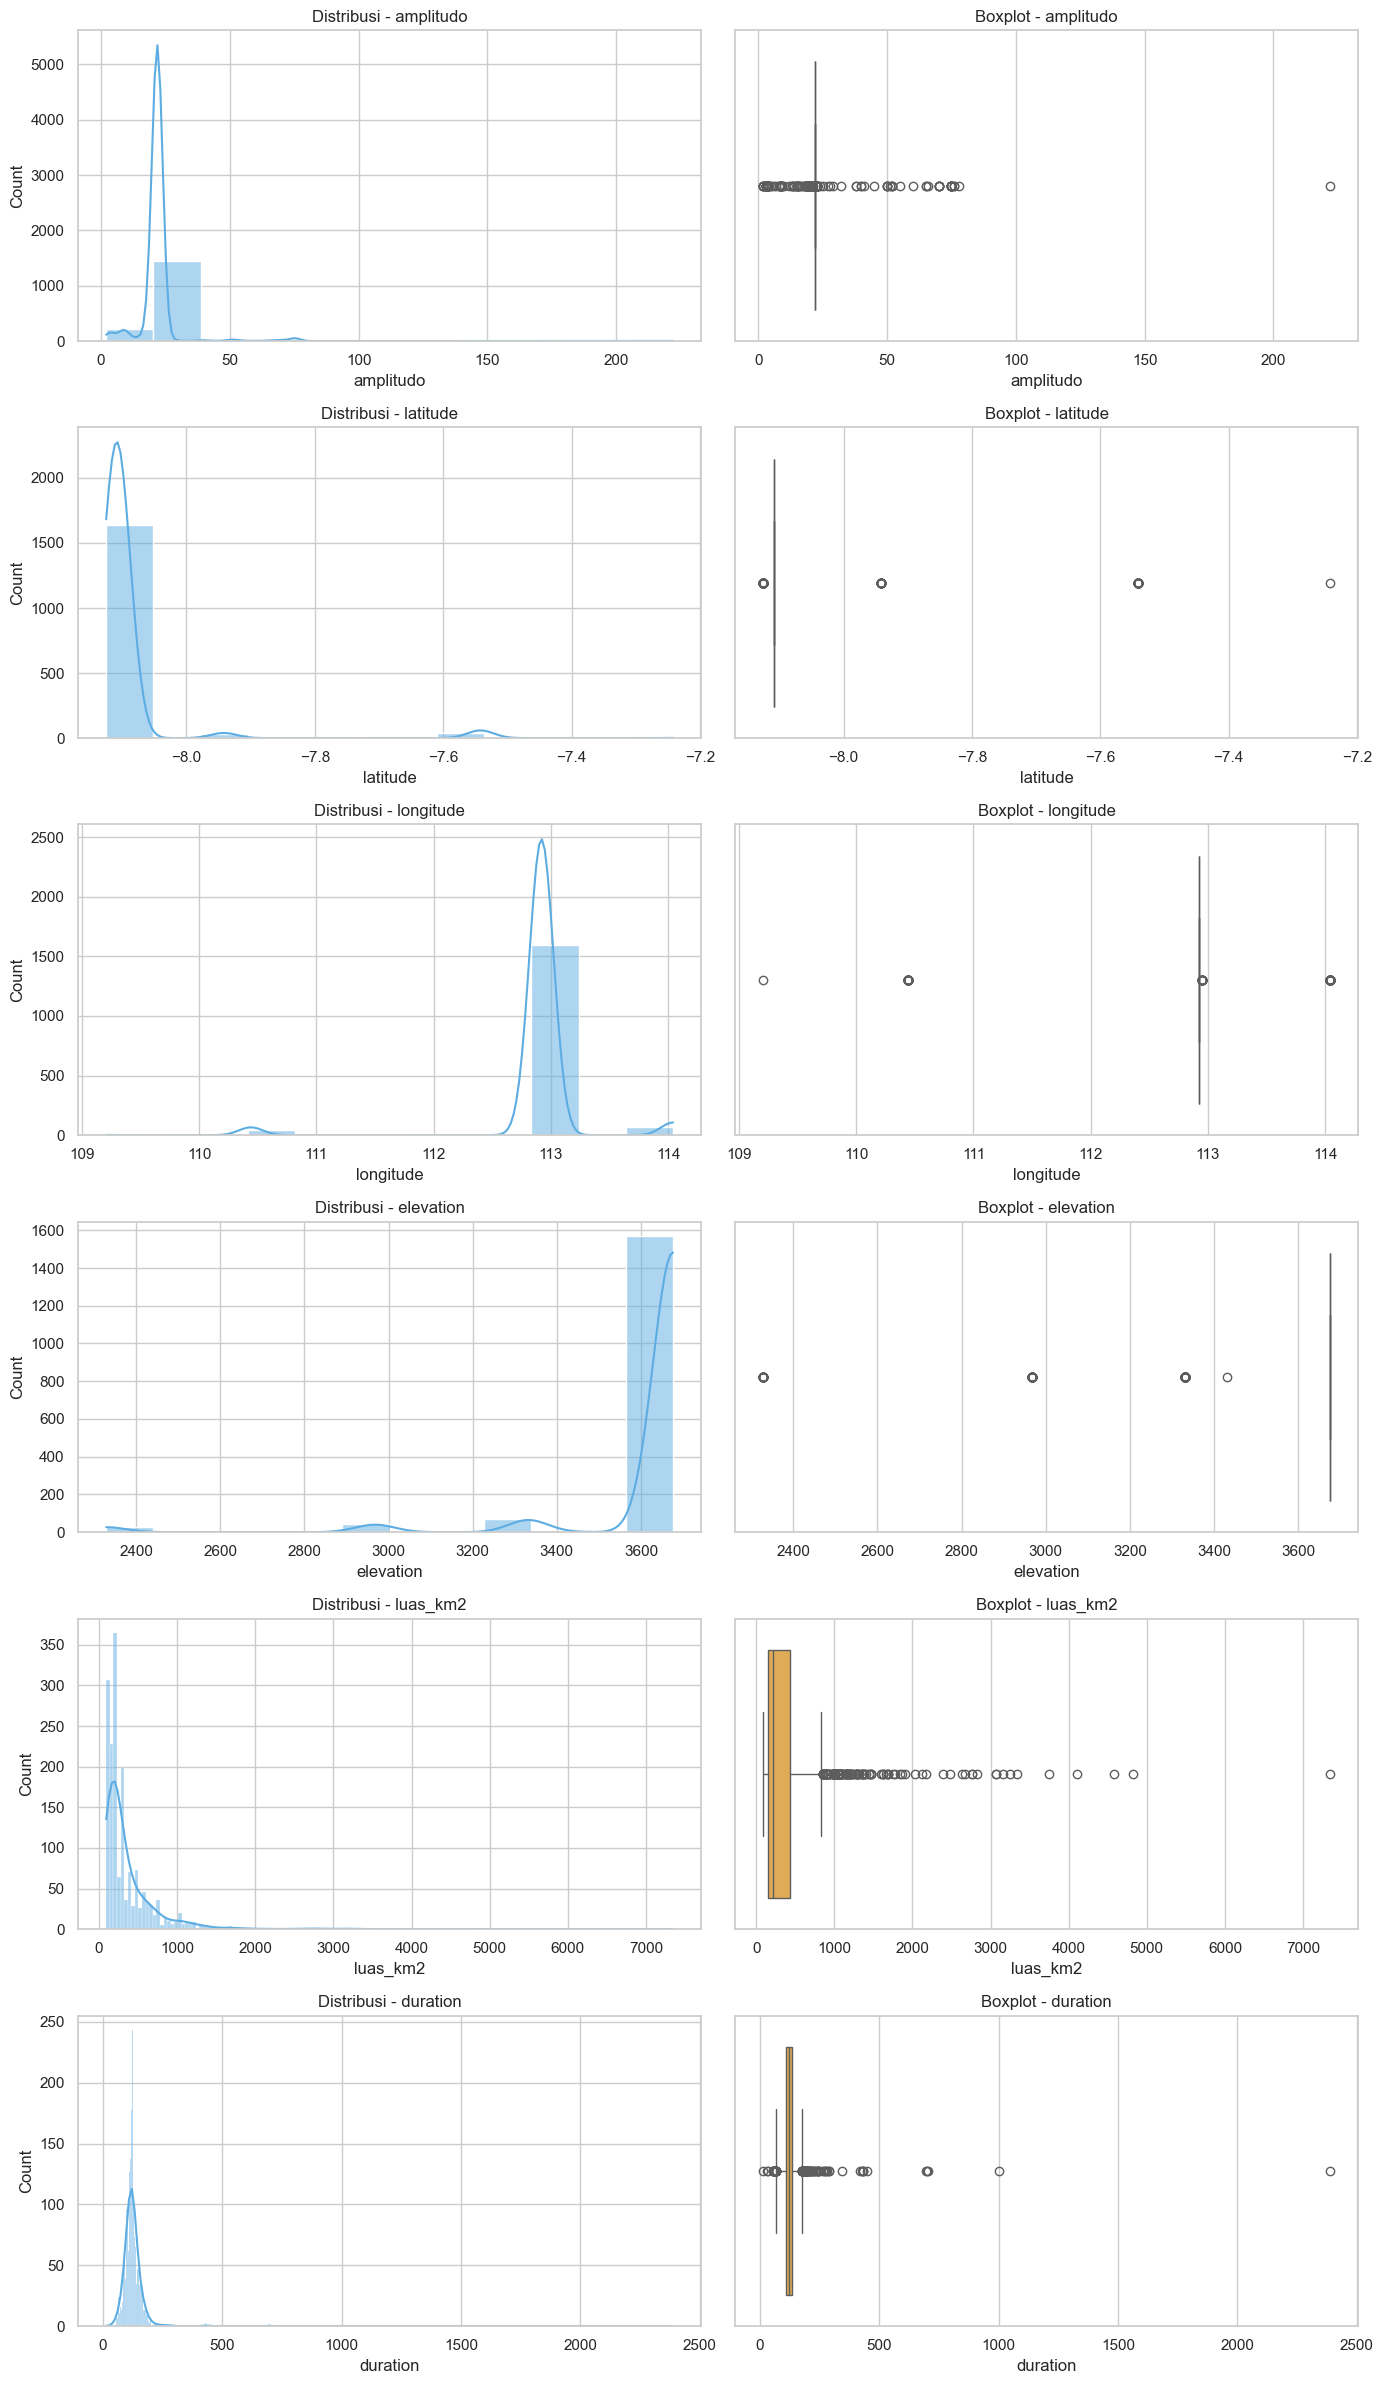

In [8]:
# Visualisasi detail 6 kolom dengan outlier terbesar
top_cols = outlier_report.head(6)['column'].tolist()

fig, axes = plt.subplots(len(top_cols), 2, figsize=(14, 4 * len(top_cols)))
if len(top_cols) == 1:
    axes = np.array([axes])

for i, col in enumerate(top_cols):
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='#5DADE2')
    axes[i, 0].set_title(f'Distribusi - {col}')

    sns.boxplot(x=df[col], ax=axes[i, 1], color='#F5B041')
    axes[i, 1].set_title(f'Boxplot - {col}')

plt.tight_layout()
plt.show()

In [9]:
# Simpan hasil EDA outlier
output_dir = DATA_PATH.parent / 'eda_outlier_outputs'
output_dir.mkdir(parents=True, exist_ok=True)

report_path = output_dir / 'outlier_iqr_report.csv'
outlier_report.to_csv(report_path, index=False)

# Simpan data dengan flag outlier gabungan (True jika outlier di minimal satu kolom numerik)
combined_mask = pd.Series(False, index=df.index)
for _, r in outlier_report.iterrows():
    c = r['column']
    m = (df[c] < r['lower_bound']) | (df[c] > r['upper_bound'])
    combined_mask = combined_mask | m.fillna(False)

df_with_flag = df.copy()
df_with_flag['is_outlier_any_numeric_iqr'] = combined_mask
flag_path = output_dir / 'dataset_with_outlier_flag.csv'
df_with_flag.to_csv(flag_path, index=False)

print('Outlier report tersimpan:', report_path)
print('Dataset + outlier flag tersimpan:', flag_path)
print('Jumlah baris outlier gabungan:', int(combined_mask.sum()))

Outlier report tersimpan: D:\Projects\volcanic_ash\modeling\eda_outlier_outputs\outlier_iqr_report.csv
Dataset + outlier flag tersimpan: D:\Projects\volcanic_ash\modeling\eda_outlier_outputs\dataset_with_outlier_flag.csv
Jumlah baris outlier gabungan: 649


## Catatan Interpretasi
- Metode IQR menandai outlier secara univariat (per kolom), jadi hasil perlu dipadukan dengan konteks domain vulkanologi.
- Outlier tidak selalu harus dihapus; bisa jadi itu kejadian erupsi ekstrem yang penting untuk model.
- Langkah lanjut: coba robust model, transformasi log pada kolom berekor panjang, atau winsorization jika dibutuhkan.